# Import libreries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
import seaborn as sb
from sklearn.preprocessing import LabelEncoder

# Reading dataset

In [2]:
df = pd.read_csv('/kaggle/input/mushroom-classification/mushrooms.csv')

# 1- EXPLORATORY DATA ANALYSIS (EDA)

In [3]:
df.head(7)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
5,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g
6,e,b,s,w,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,n,m


In [4]:
df.tail(5)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l
8123,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,o,c,l


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [6]:
sum(df.duplicated())

0

In [7]:
df.shape

(8124, 23)

In [8]:
df.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

In [9]:
#finding null values
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [10]:
(df == 0).sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [11]:
# Assuming df is your DataFrame
unique_counts = df.nunique()

# Print the number of unique values for each column
print(unique_counts)

class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64


In [12]:
df.describe().T

,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


In [13]:
# drop veil-Type because we just have one of this feature
df=df.drop(columns=['veil-type'])

# 2-Plots

# 2-1- categorical features distribution Plot

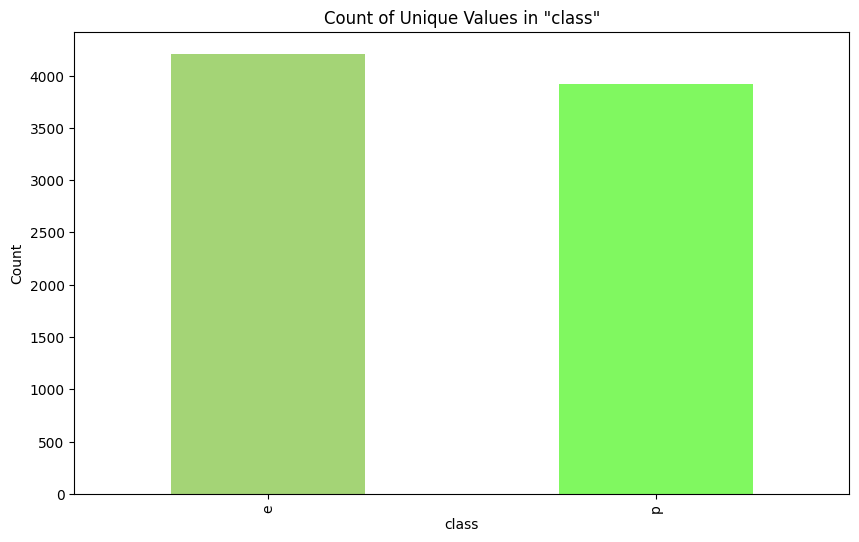

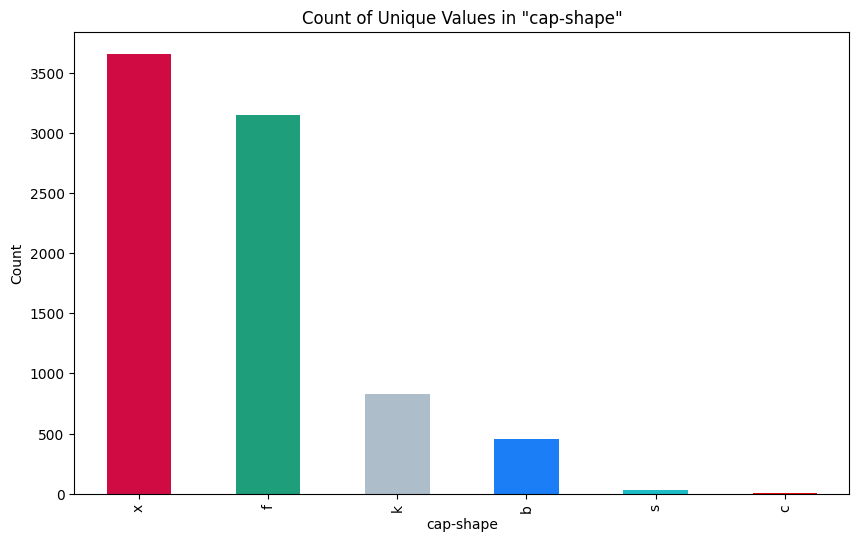

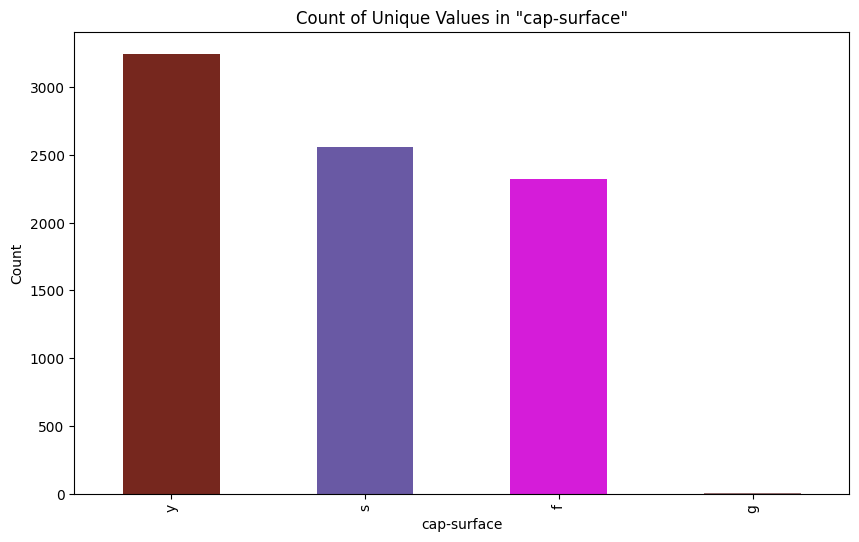

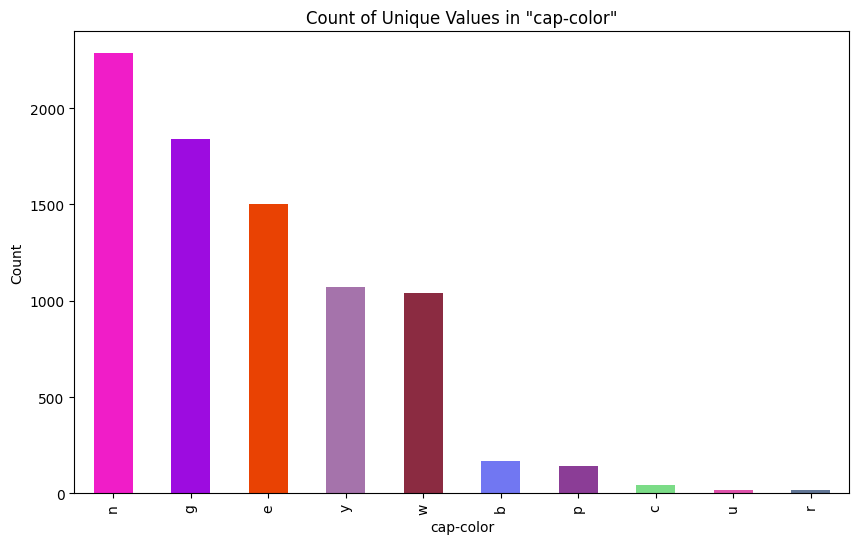

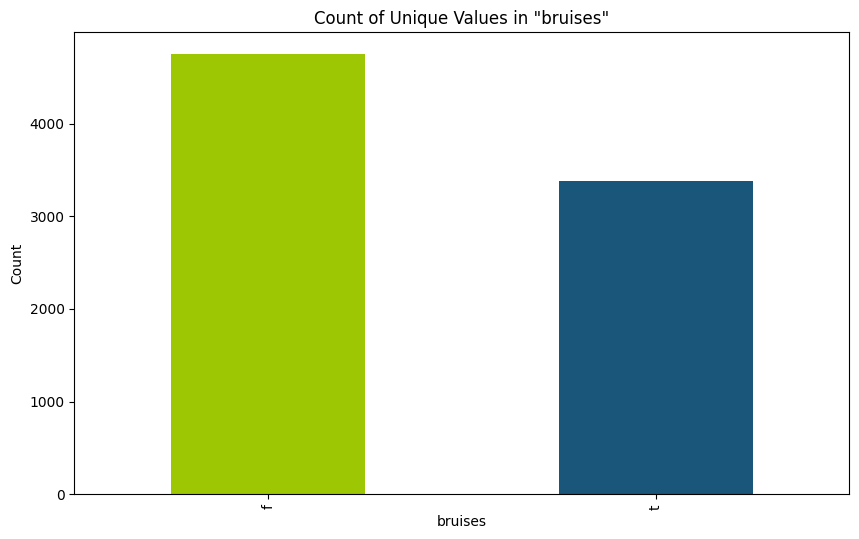

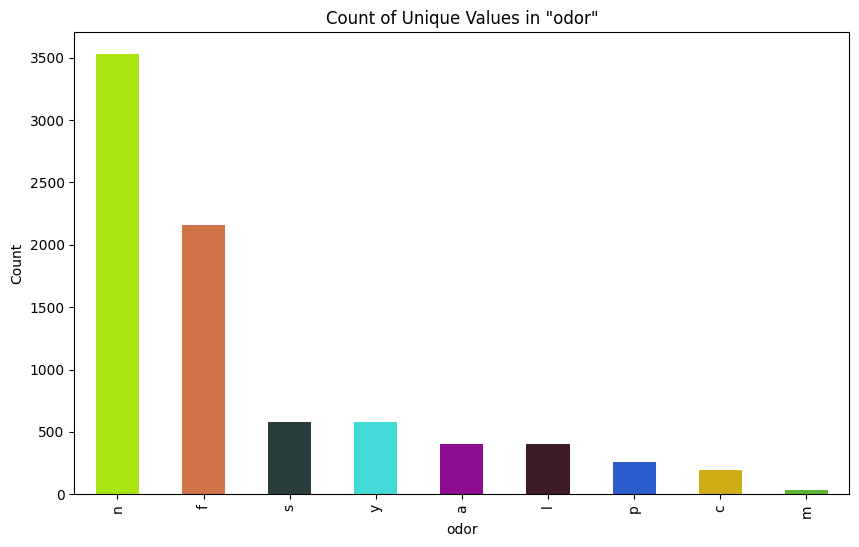

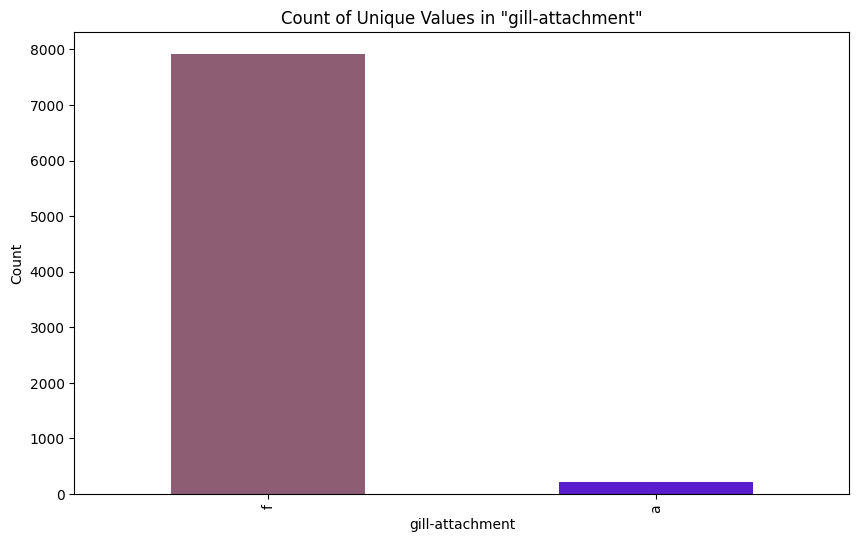

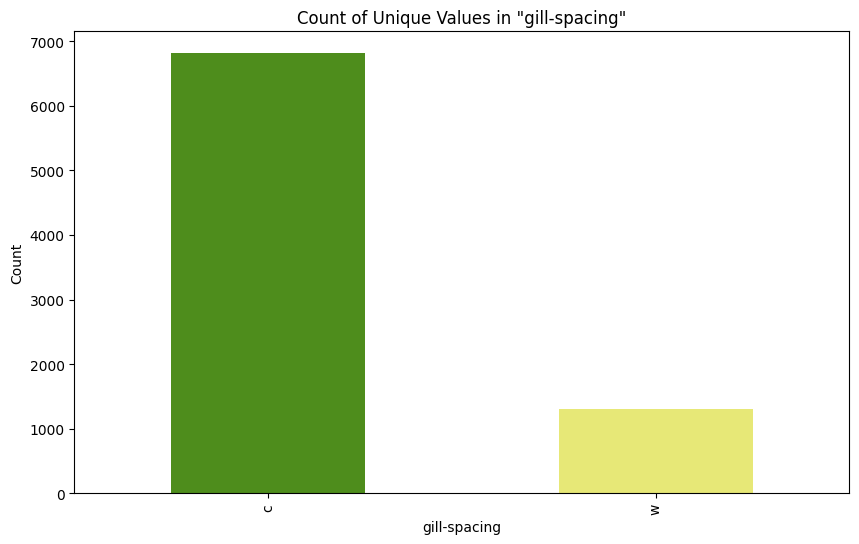

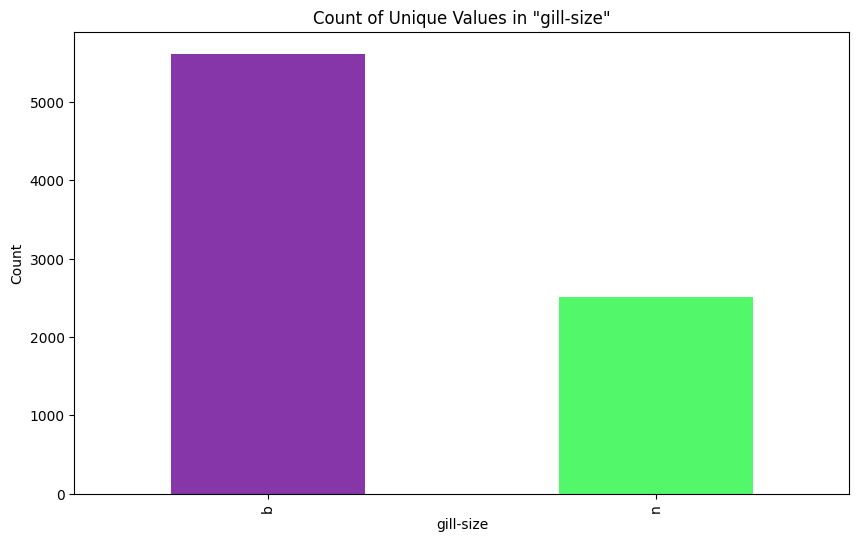

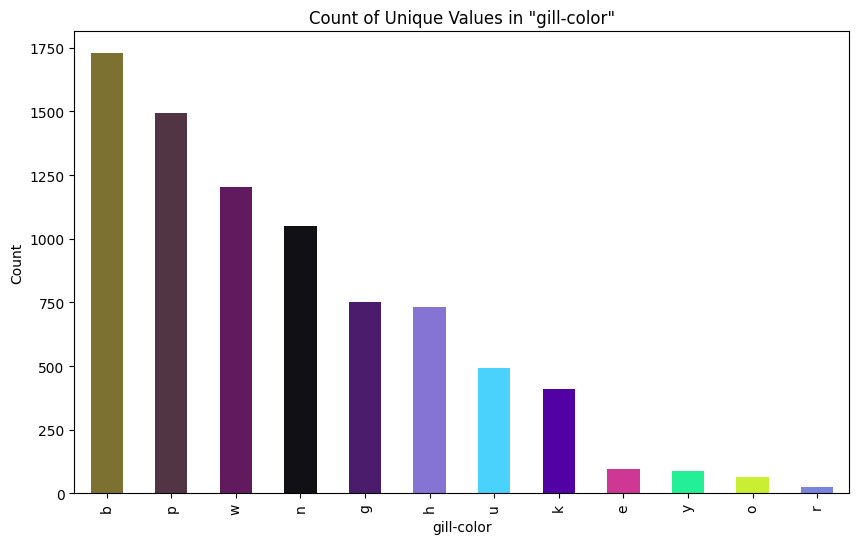

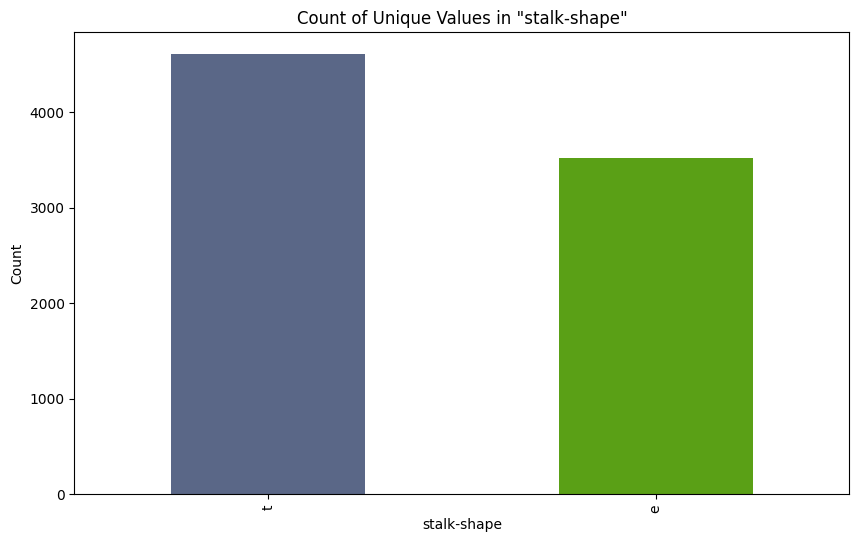

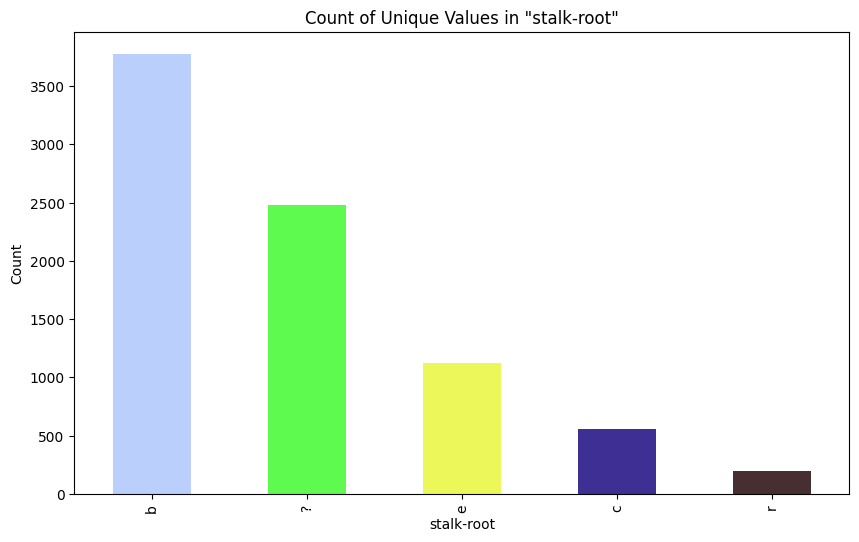

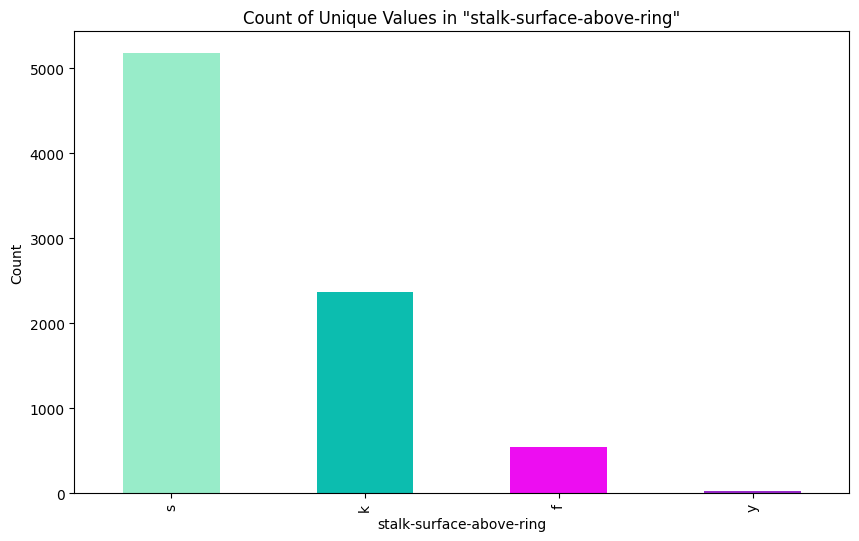

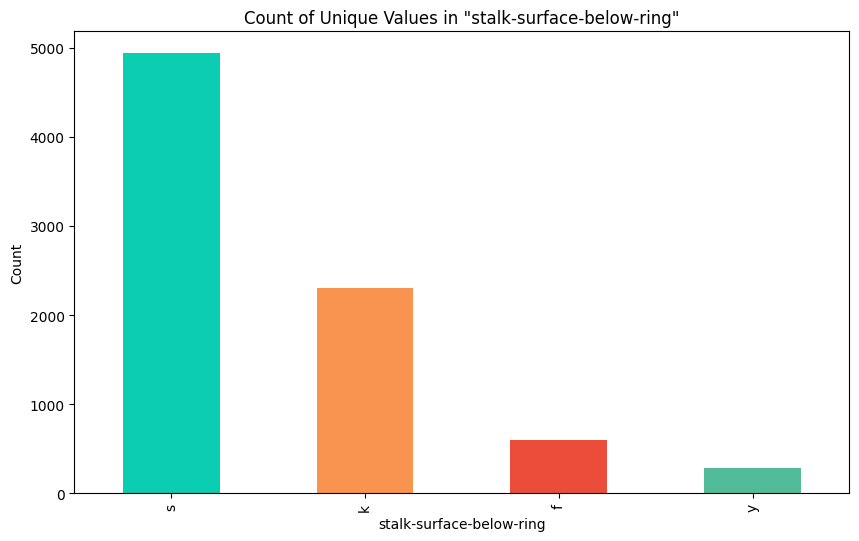

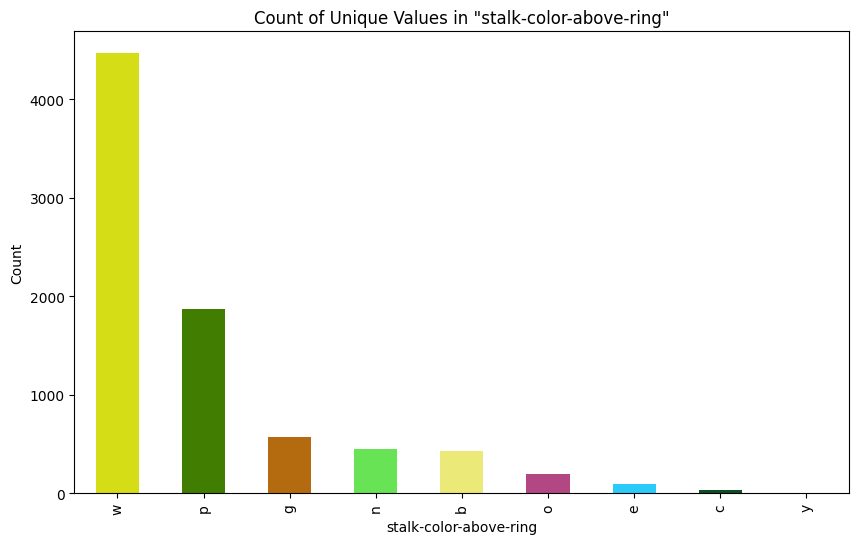

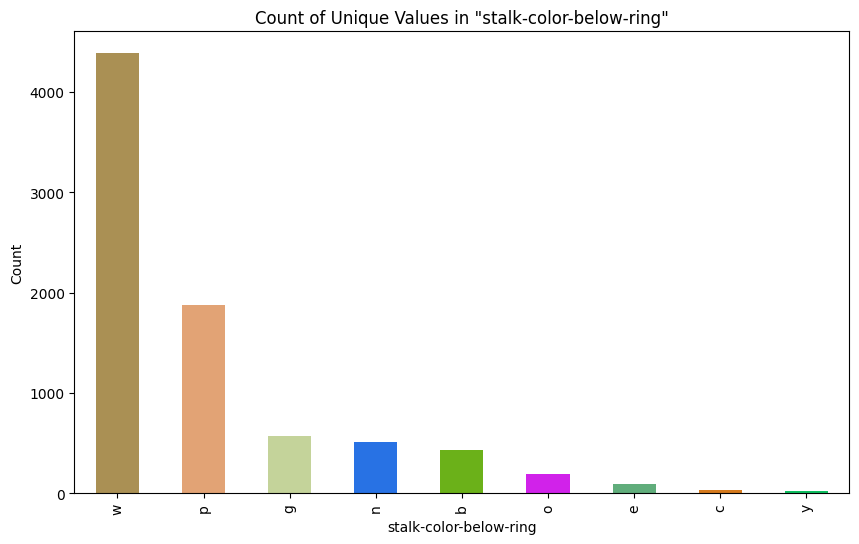

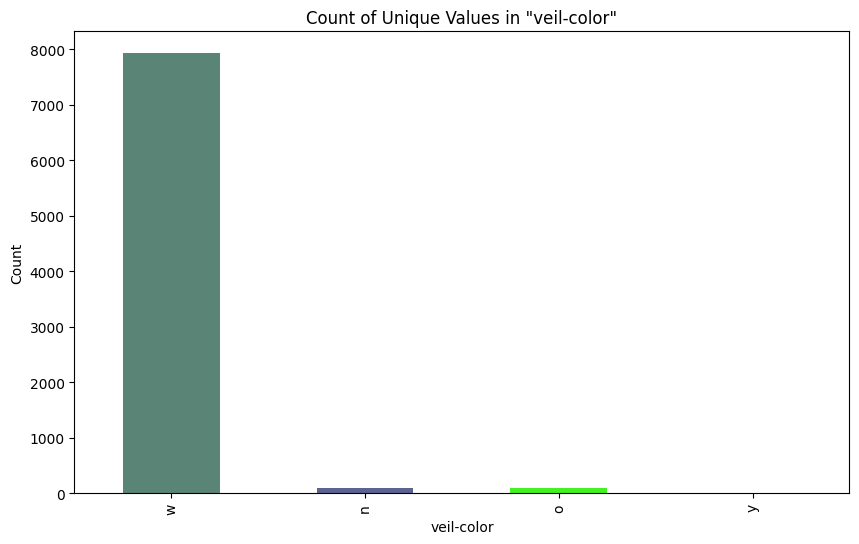

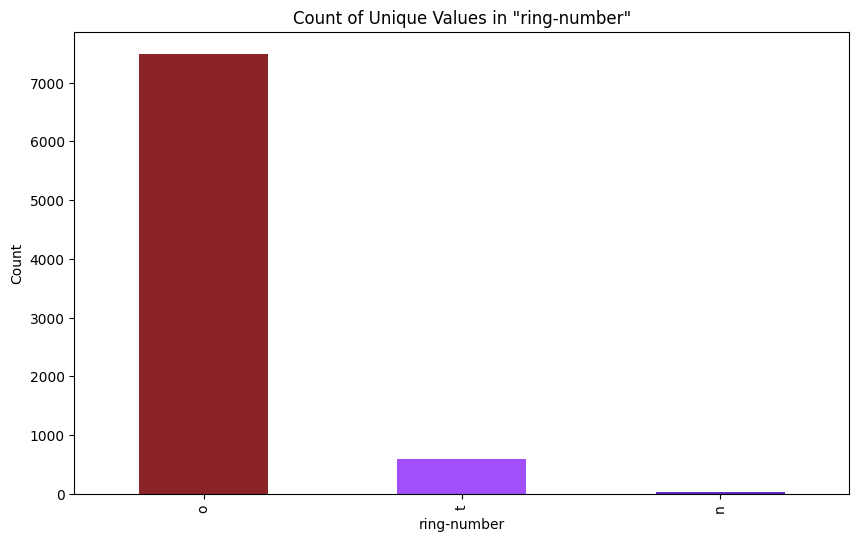

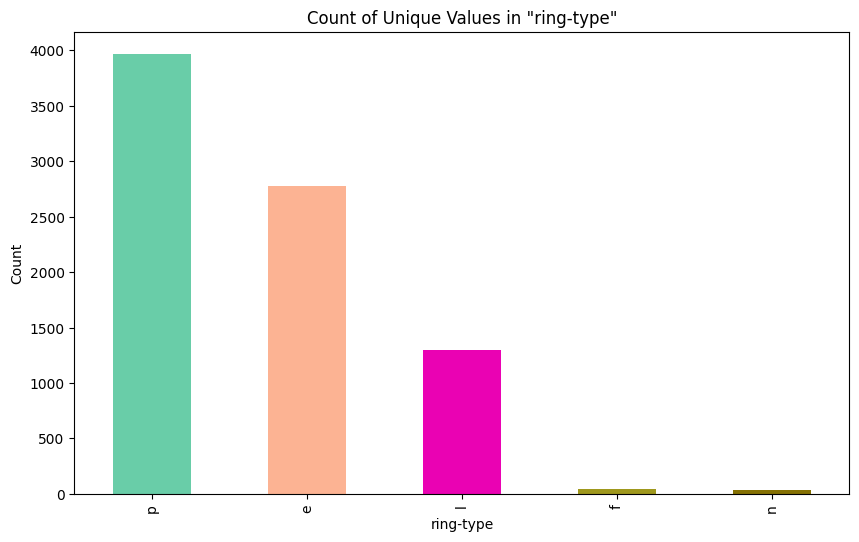

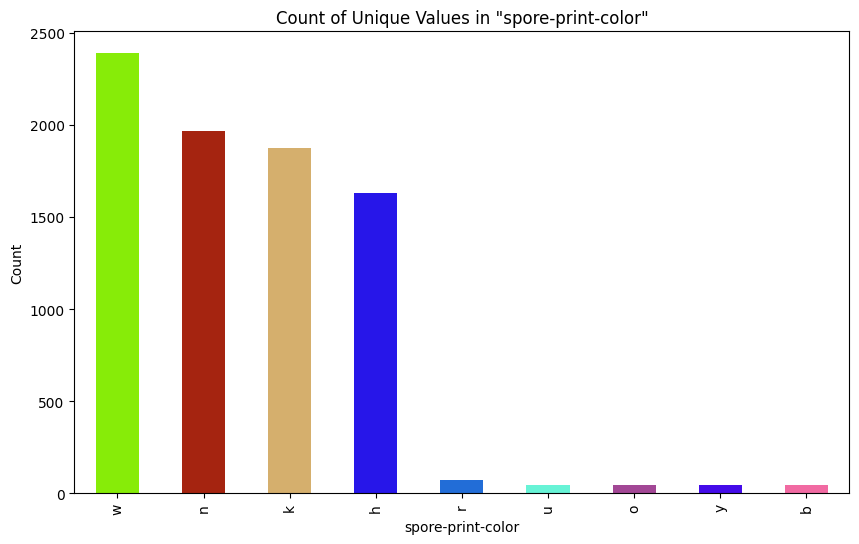

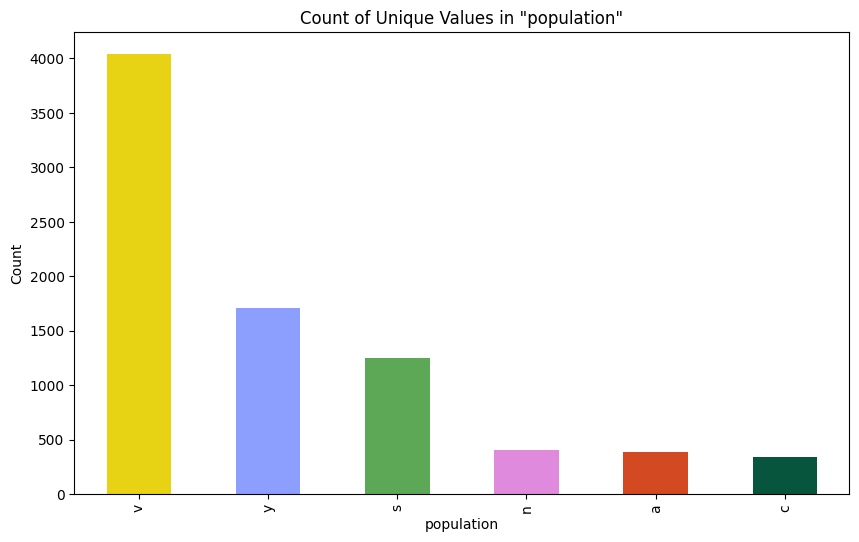

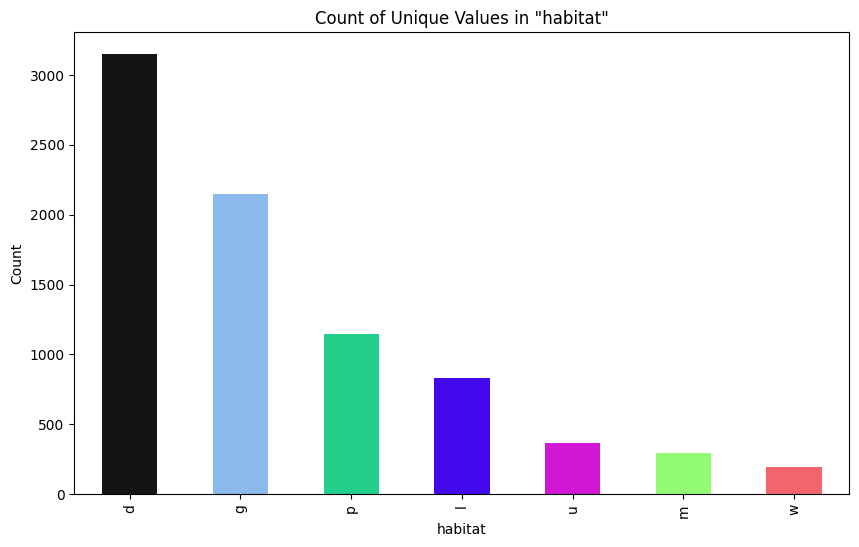

In [14]:
import numpy as np
def generate_random_colors(n):
    """Generate a list of n random colors."""
    colors = np.random.rand(n, 3)  # Generates an n x 3 array of random RGB values
    return colors


for column in df.columns:
    value_counts = df[column].value_counts()

    plt.figure(figsize=(10, 6))

    # Generate random colors for each unique value
    colors = generate_random_colors(len(value_counts))

    # Plot the bar chart
    value_counts.plot(kind='bar', color=colors)

    plt.title(f'Count of Unique Values in "{column}"')
    plt.xlabel(column)
    plt.ylabel('Count')

    plt.show()

# 2-2- Seperating target and data

In [15]:
#seprating target and data
x=df.drop(['class'],axis=1)
y=df['class']

In [16]:
#Encoding the data
import pandas as pd
x = pd.get_dummies(x)

In [17]:
#Encoding the target data
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

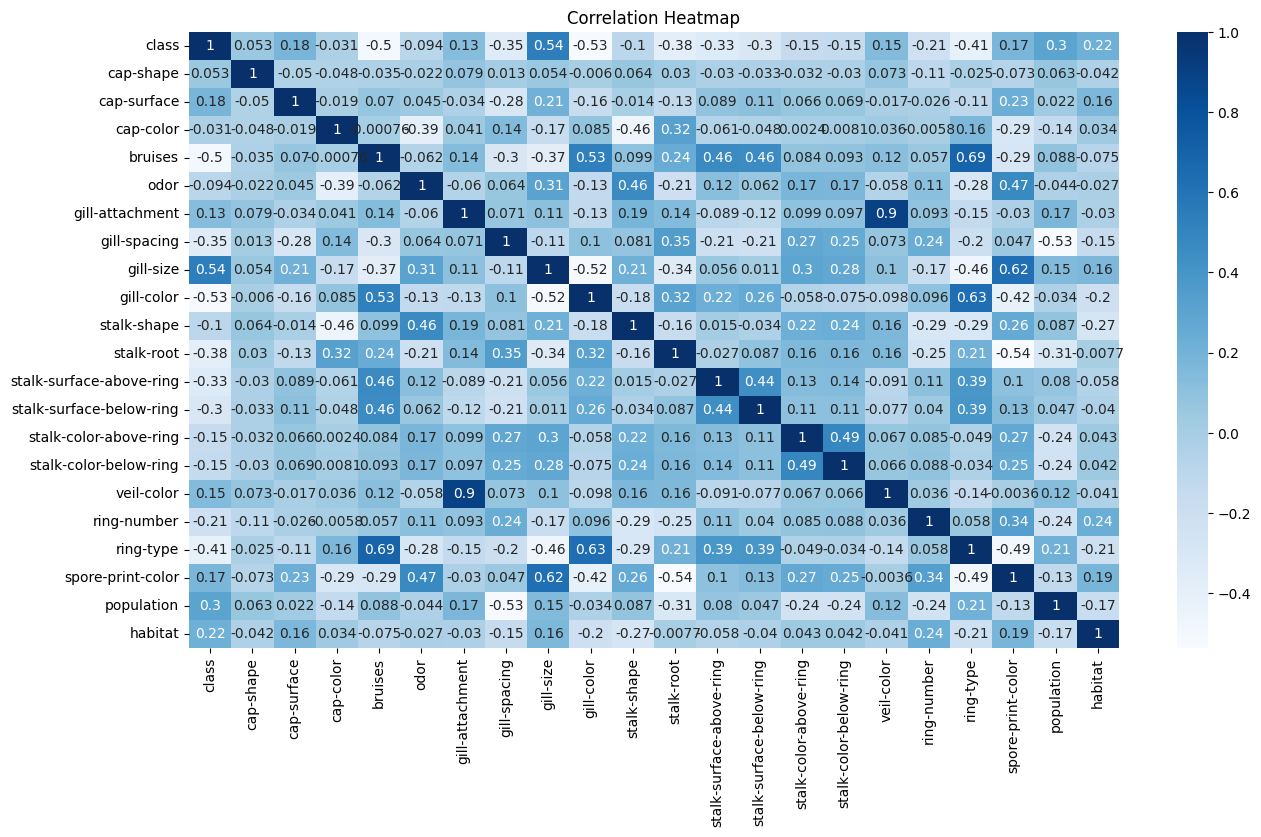

In [18]:
#Heatmap of Correlation Matrix
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply label encoding to each column
df_encoded = df.apply(label_encoder.fit_transform)

numeric = df_encoded

# defining the figure size
plt.figure(figsize=(15, 8))
# plotting the heatmap
sns.heatmap(numeric.corr(), annot=True, cbar=True,cmap='Blues')
# set the title
plt.title('Correlation Heatmap')
# show the plot
plt.show()

**Observation:**

 - There is high corrolation between target and gill size,gill color

# 2-4-Pairplot

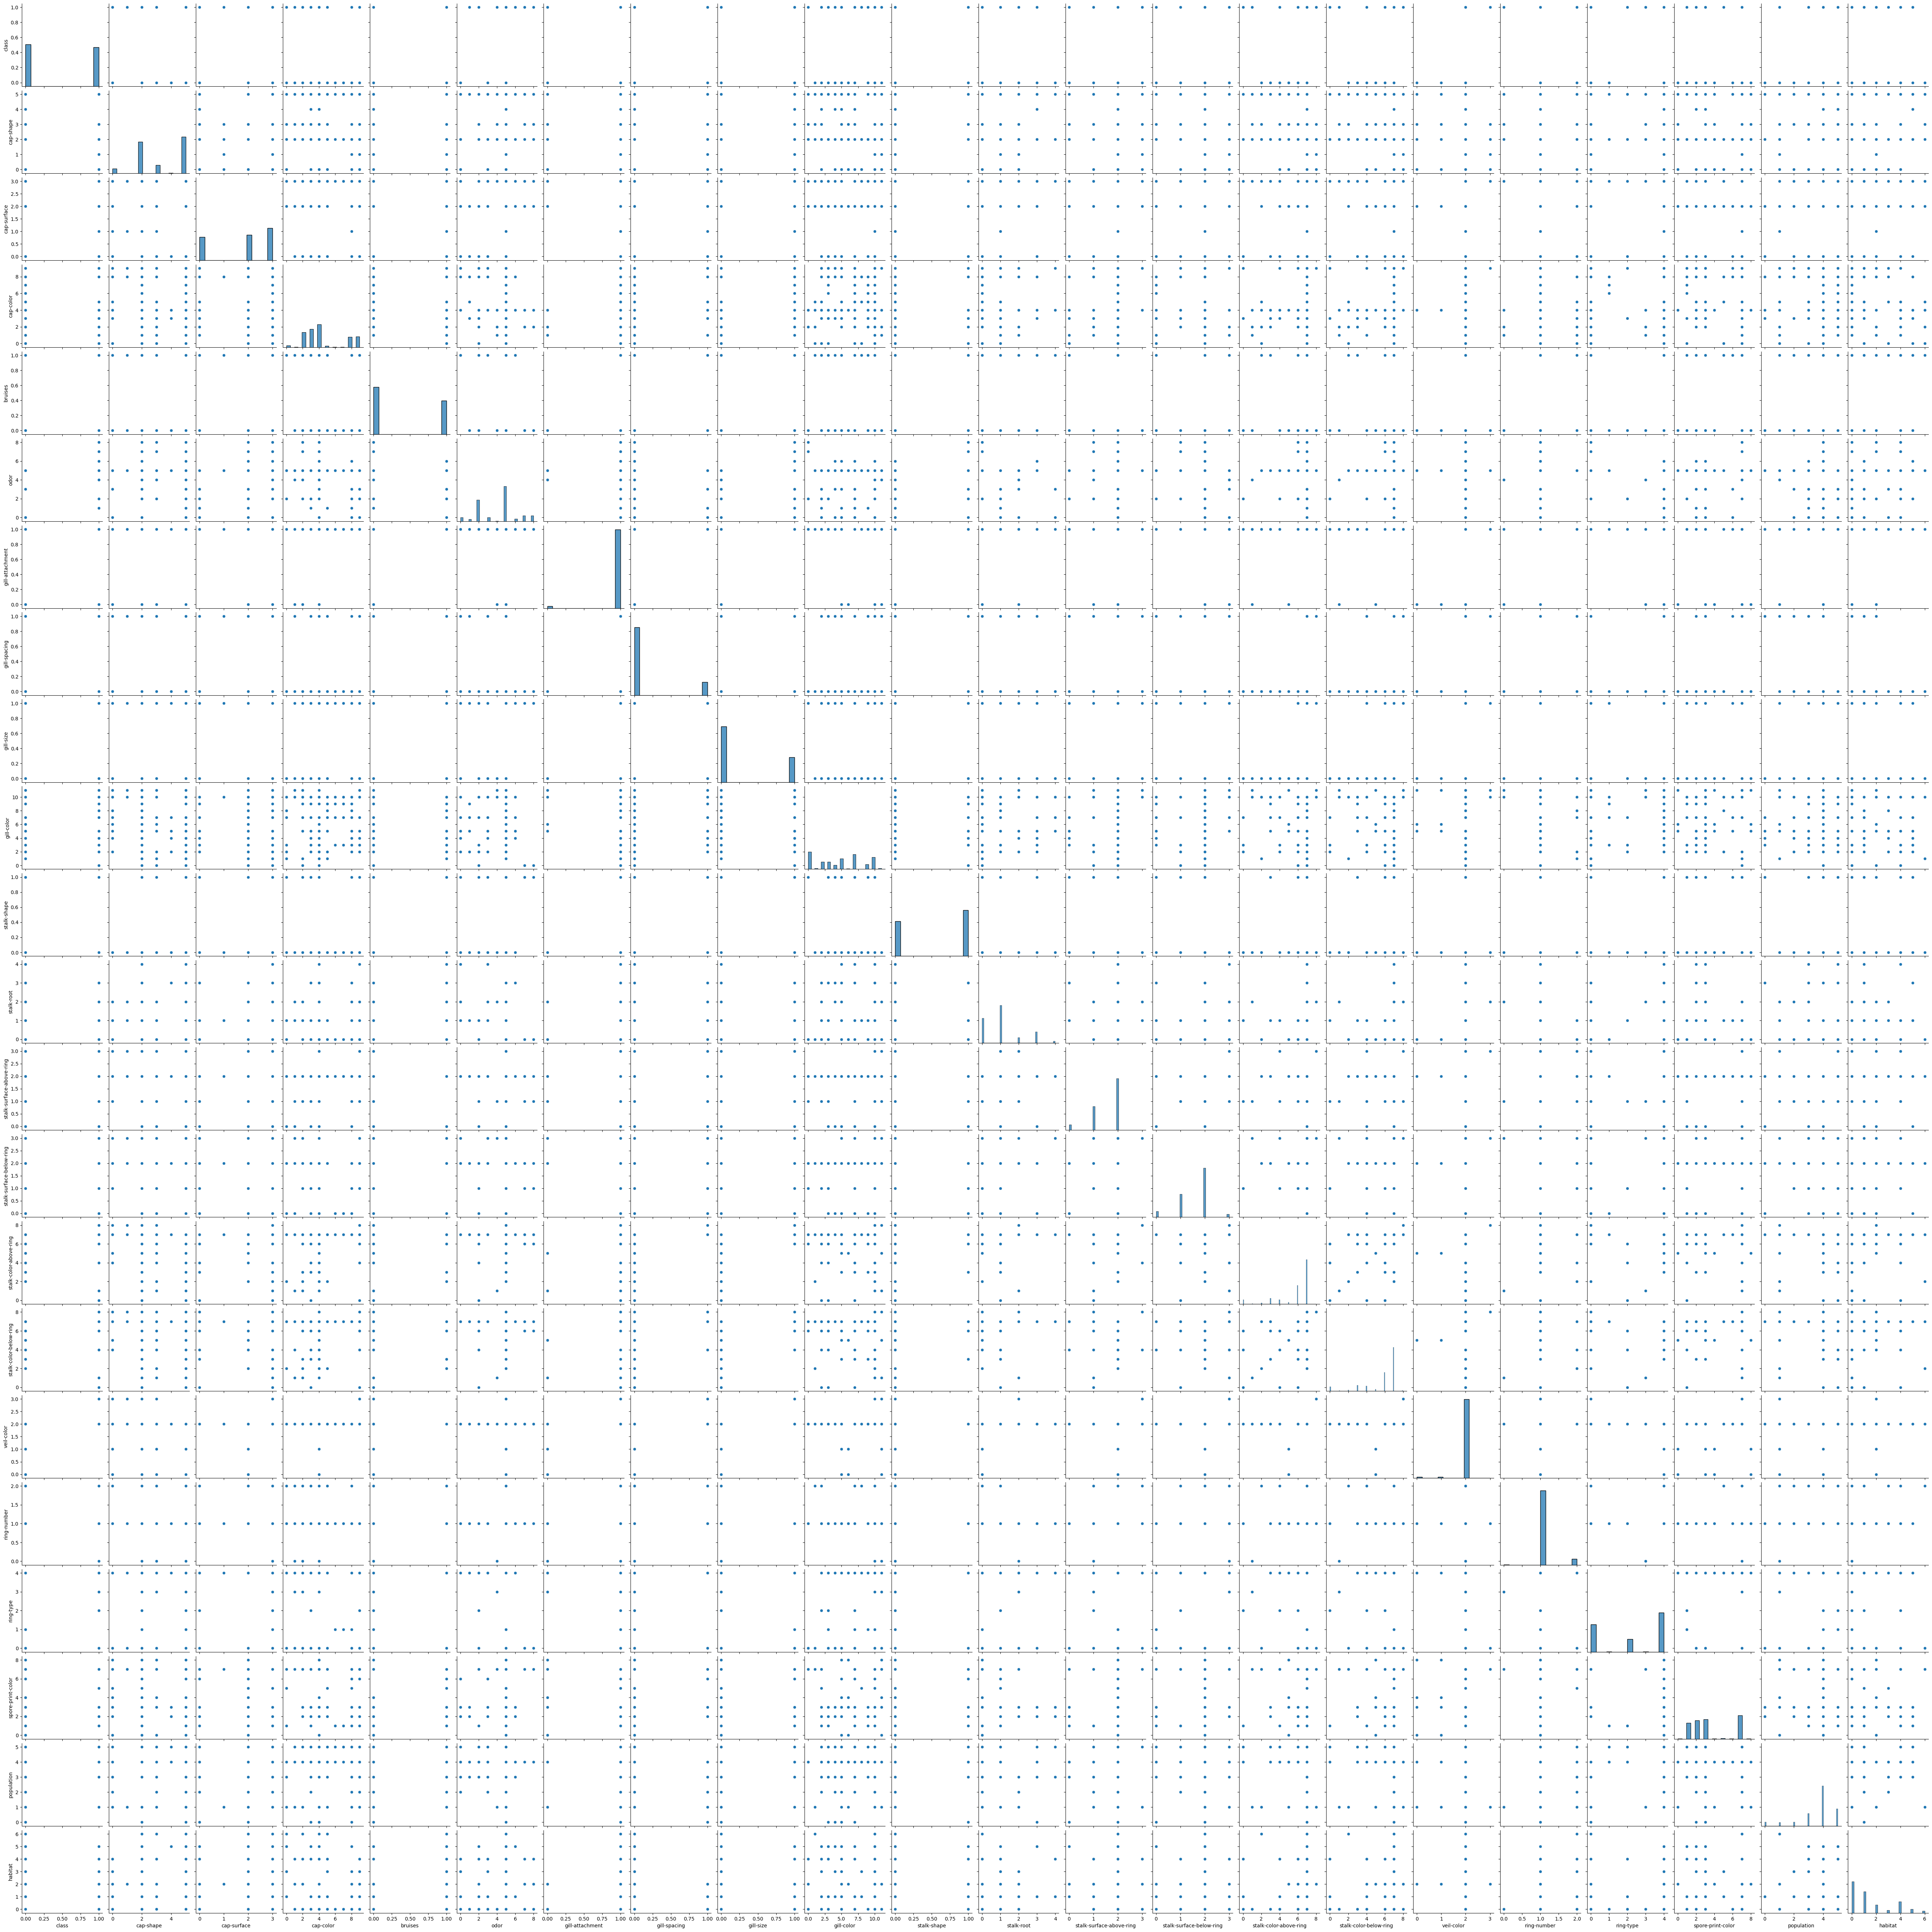

In [19]:
#Pairplot fro graphical corrolation between parameters
#Removing warnings

filterwarnings("ignore", category=FutureWarning)
#Paه plot
sns.pairplot(df_encoded)

# 2-5- Target distribution

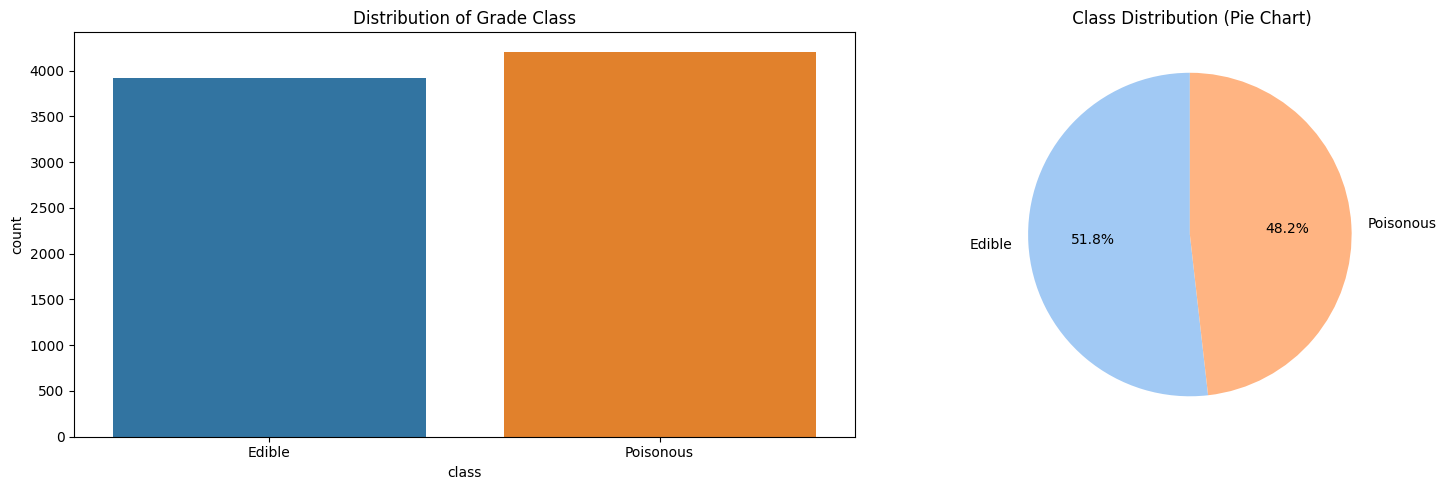

In [20]:
# Set custom labels
labels = ["Edible", "Poisonous"]
ticks = range(len(labels))

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot the count plot on the first subplot
sns.countplot(data=df, x='class', ax=axes[0])
axes[0].set_title('Distribution of Grade Class')
axes[0].set_xticks(ticks)
axes[0].set_xticklabels(labels)

# Calculate counts for the pie chart
grade_counts = df['class'].value_counts().sort_index()

# Plot the pie chart on the second subplot
axes[1].pie(grade_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
axes[1].set_title(' Class Distribution (Pie Chart)')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

# 3- seprating data to train-test-spilit

In [21]:
#seprating data to train-test-spilit
from sklearn.model_selection import train_test_split
import numpy as np



# Split the data into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)
x_train.shape,x_test.shape

((5686, 116), (2438, 116))

# 4-classification Models

# a-Accuracy function

In [22]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

def calculate_metrics(y_test, y_pred_test):
    # Calculate precision
    precision_test = precision_score(y_true=y_test, y_pred=y_pred_test, average='weighted')

    # Calculate recall
    recall_test = recall_score(y_true=y_test, y_pred=y_pred_test, average='weighted')

    # Calculate confusion matrix
    conf_matrix = confusion_matrix(y_true=y_test, y_pred=y_pred_test)

    return {
        'precision_test': precision_test,
        'recall_test': recall_test,
        'confusion_matrix': conf_matrix
    }

# A-Initialize results dataframe

In [23]:
# Sample DataFrame with metrics placeholders
acc = np.zeros((12, 2))
columns = ['precision', 'recall']
rows = ['Naive bayes', 'KNN', 'Decision tree', 'Random forest', 'SVM', 'LR', 'ANN', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'AdaBoost', 'Extra Trees']
results_df = pd.DataFrame(acc, columns=columns, index=rows)

# 5-1-Naive bayes model

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report


# Initialize the GaussianNB classifier
naive_bayes = GaussianNB()

# Define the parameter grid for GaussianNB
param_grid = {
    'var_smoothing': [1e-15,1e-9, 1e-8, 1e-7, 1e-6, 1e-0]  # Small values to smooth variance
}

# Initialize GridSearchCV with GaussianNB
grid_search = GridSearchCV(estimator=naive_bayes, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(x_train, y_train)

# Retrieve the best estimator
best_naive_bayes = grid_search.best_estimator_

# Predict with the best model
y_pred_train_NB = best_naive_bayes.predict(x_train)
y_pred_test_NB = best_naive_bayes.predict(x_test)


# Calculate metrics
metrics = calculate_metrics(y_test, y_pred_test_NB)

# Print the best parameters found by GridSearchCV
print("Best parameters found by grid search:")
print(grid_search.best_params_)

results_df.iloc[0]=[metrics['precision_test'],metrics['recall_test']]

# Print metrics
print(f"Precision (Test): {metrics['precision_test']:.2f}")
print(f"Recall (Test): {metrics['recall_test']:.2f}")
print("Confusion Matrix:")
print(metrics['confusion_matrix'])


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters found by grid search:
{'var_smoothing': 1e-06}
Precision (Test): 0.99
Recall (Test): 0.99
Confusion Matrix:
[[1223   34]
 [   1 1180]]


**obervation :**

there is just one FN in all predictions

# 5-2- KNN Model

In [25]:
#KNN grid search
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNeighborsClassifier
knn = KNeighborsClassifier()

# Define the parameter grid
param_grid = {
    'n_neighbors': [25],
    'weights': [ 'distance'],
    'p': [1],
    'leaf_size': [50]
}

# Initialize GridSearchCV with KNeighborsClassifier
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(x_train, y_train)

# Retrieve the best estimator
best_knn = grid_search.best_estimator_

# Predict with the best model
y_pred_train_knn = best_knn.predict(x_train)
y_pred_test_knn = best_knn.predict(x_test)

# Print the best parameters found by GridSearchCV
print("Best parameters found by grid search:")
print(grid_search.best_params_)


# Calculate metrics
metrics = calculate_metrics(y_test, y_pred_test_knn)

results_df.iloc[1]=[metrics['precision_test'],metrics['recall_test']]

# Print metrics
print(f"Precision (Test): {metrics['precision_test']:.2f}")
print(f"Recall (Test): {metrics['recall_test']:.2f}")
print("Confusion Matrix:")
print(metrics['confusion_matrix'])


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters found by grid search:
{'leaf_size': 50, 'n_neighbors': 25, 'p': 1, 'weights': 'distance'}
Precision (Test): 1.00
Recall (Test): 1.00
Confusion Matrix:
[[1257    0]
 [   0 1181]]


**obervation:** 

there is just 0 FP and FN

# 5-3- Decision Tree

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Initialize the DecisionTreeClassifier
decision_tree = DecisionTreeClassifier()

# Define the parameter grid for DecisionTreeClassifier
param_grid = {
    #'criterion': ['gini', 'entropy'],
    'max_depth': [6],
    'min_samples_split': [10],
    'min_samples_leaf': [2],
    #'max_features': [None, 'auto', 'sqrt', 'log2']
}

# Initialize GridSearchCV with DecisionTreeClassifier
grid_search = GridSearchCV(estimator=decision_tree, param_grid=param_grid, cv=5, verbose=1, n_jobs=1)

# Fit the grid search to the data
grid_search.fit(x_train, y_train)

# Retrieve the best estimator
best_decision_tree = grid_search.best_estimator_

# Predict with the best model
y_pred_train_dt = best_decision_tree.predict(x_train)
y_pred_test_dt = best_decision_tree.predict(x_test)


# Print the best parameters found by GridSearchCV
print("Best parameters found by grid search:")
print(grid_search.best_params_)

# Calculate metrics
metrics = calculate_metrics(y_test, y_pred_test_dt)

results_df.iloc[2]=[metrics['precision_test'],metrics['recall_test']]

# Print metrics
print(f"Precision (Test): {metrics['precision_test']:.2f}")
print(f"Recall (Test): {metrics['recall_test']:.2f}")
print("Confusion Matrix:")
print(metrics['confusion_matrix'])

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters found by grid search:
{'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 10}
Precision (Test): 1.00
Recall (Test): 1.00
Confusion Matrix:
[[1257    0]
 [   0 1181]]


**obervation :** 

there is just 0 FP and FN

# 5-4- Random Forest model

In [27]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier
random_forest = RandomForestClassifier()

# Define the parameter grid for RandomForestClassifier
param_grid_rf = {
    'n_estimators': [20], #The number of trees in the forest.
    'max_depth': [ 1000], #The maximum depth of each tree in the forest.
    'min_samples_split': [10], #The minimum number of samples required to split an internal node.
    'min_samples_leaf': [4], #The minimum number of samples required to be at a leaf node.
    #'bootstrap': [True, False] #Whether bootstrap samples are used when building trees.
}

# Initialize GridSearchCV with RandomForestClassifier
grid_search_rf = GridSearchCV(estimator=random_forest, param_grid=param_grid_rf, cv=5, verbose=1, n_jobs=-1)

# Fit the grid search to the data
grid_search_rf.fit(x_train, y_train)

# Retrieve the best estimator
best_random_forest = grid_search_rf.best_estimator_

# Predict with the best model
y_pred_train_rf = best_random_forest.predict(x_train)
y_pred_test_rf = best_random_forest.predict(x_test)

# Print the best parameters found by GridSearchCV
print("Best parameters found by grid search:")
print(grid_search_rf.best_params_)

# Calculate metrics
metrics = calculate_metrics(y_test, y_pred_test_rf)

results_df.iloc[3]=[metrics['precision_test'],metrics['recall_test']]

# Print metrics
print(f"Precision (Test): {metrics['precision_test']:.2f}")
print(f"Recall (Test): {metrics['recall_test']:.2f}")
print("Confusion Matrix:")
print(metrics['confusion_matrix'])

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters found by grid search:
{'max_depth': 1000, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 20}
Precision (Test): 1.00
Recall (Test): 1.00
Confusion Matrix:
[[1257    0]
 [   0 1181]]


**obervation :** 

there is just 0 FP and FN

# 5-5- SVM Model

In [28]:
from sklearn.svm import SVC

# Initialize the SVC (Support Vector Classifier)
svc = SVC()

# Define the parameter grid for SVC
param_grid_svc = {
    'C': [1],                   # Regularization parameter,Controls the trade-off between achieving a low training error and minimizing the model complexity.
    'kernel': ['linear', 'rbf', 'poly'],      # Specifies the type of kernel function used to transform the data into a higher-dimensional space. Type of kernel.
    'gamma': ['scale', 'auto']                #  Controls the influence of a single training example; it defines how far the influence of a single training example reaches. Kernel coefficient for 'rbf', 'poly', 'sigmoid'.
}

# Initialize GridSearchCV with SVC
grid_search_svc = GridSearchCV(estimator=svc, param_grid=param_grid_svc, cv=5, verbose=1, n_jobs=-1)

# Fit the grid search to the data
grid_search_svc.fit(x_train, y_train)

# Retrieve the best estimator
best_svc = grid_search_svc.best_estimator_

# Predict with the best model
y_pred_train_svc = best_svc.predict(x_train)
y_pred_test_svc = best_svc.predict(x_test)


# Print the best parameters found by GridSearchCV
print("Best parameters found by grid search:")
print(grid_search_svc.best_params_)

# Calculate metrics
metrics = calculate_metrics(y_test, y_pred_test_svc)

results_df.iloc[4]=[metrics['precision_test'],metrics['recall_test']]

# Print metrics
print(f"Precision (Test): {metrics['precision_test']:.2f}")
print(f"Recall (Test): {metrics['recall_test']:.2f}")
print("Confusion Matrix:")
print(metrics['confusion_matrix'])

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters found by grid search:
{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Precision (Test): 1.00
Recall (Test): 1.00
Confusion Matrix:
[[1257    0]
 [   0 1181]]


# 5-6- Logestic regresssion

In [29]:
from sklearn.linear_model import LogisticRegression

# Initialize the LogisticRegression
log_reg = LogisticRegression(max_iter=1000)  # Increase max_iter to ensure convergence

# Define the parameter grid for LogisticRegression
param_grid_log_reg = {
    'C': [10],          # Regularization parameter
    'penalty': ['l1', 'l2'],               # Penalties to test
    'solver': ['liblinear', 'saga']        # Solvers to test (liblinear supports l1 and l2, saga supports l1, l2, and elasticnet)
}

# Initialize GridSearchCV with LogisticRegression
grid_search_log_reg = GridSearchCV(estimator=log_reg, param_grid=param_grid_log_reg, cv=5, verbose=1, n_jobs=-1, error_score='raise')

# Fit the grid search to the data
grid_search_log_reg.fit(x_train, y_train)

# Retrieve the best estimator
best_log_reg = grid_search_log_reg.best_estimator_

# Predict with the best model
y_pred_train_log_reg = best_log_reg.predict(x_train)
y_pred_test_log_reg = best_log_reg.predict(x_test)


# Print the best parameters found by GridSearchCV
print("Best parameters found by grid search:")
print(grid_search_log_reg.best_params_)

# Calculate metrics
metrics = calculate_metrics(y_test, y_pred_test_log_reg)

results_df.iloc[5]=[metrics['precision_test'],metrics['recall_test']]

# Print metrics
print(f"Precision (Test): {metrics['precision_test']:.2f}")
print(f"Recall (Test): {metrics['recall_test']:.2f}")
print("Confusion Matrix:")
print(metrics['confusion_matrix'])

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best parameters found by grid search:
{'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Precision (Test): 1.00
Recall (Test): 1.00
Confusion Matrix:
[[1257    0]
 [   0 1181]]


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


# 5-7- ANN Model

In [30]:
from sklearn.neural_network import MLPClassifier

# Initialize the MLPClassifier (Artificial Neural Network)
mlp = MLPClassifier(max_iter=1000)  # Increase max_iter to ensure convergence

# Define the parameter grid for MLPClassifier
param_grid_mlp = {
    'hidden_layer_sizes': [(150, 50)],  # Different network architectures
    'activation': ['relu'],  # Activation functions
    'solver': ['sgd'],  # Optimization algorithms
    'alpha': [ 0.001],  # Regularization term
    'learning_rate': ['constant']  # Learning rate schedules
}

# Initialize GridSearchCV with MLPClassifier
grid_search_mlp = GridSearchCV(estimator=mlp, param_grid=param_grid_mlp, cv=5, verbose=1, n_jobs=-1, error_score='raise')

# Fit the grid search to the data
grid_search_mlp.fit(x_train, y_train)

# Retrieve the best estimator
best_mlp = grid_search_mlp.best_estimator_

# Predict with the best model
y_pred_train_mlp = best_mlp.predict(x_train)
y_pred_test_mlp = best_mlp.predict(x_test)


# Print the best parameters found by GridSearchCV
print("Best parameters found by grid search:")
print(grid_search_mlp.best_params_)

# Calculate metrics
metrics = calculate_metrics(y_test, y_pred_test_mlp)

results_df.iloc[6]=[metrics['precision_test'],metrics['recall_test']]

# Print metrics
print(f"Precision (Test): {metrics['precision_test']:.2f}")
print(f"Recall (Test): {metrics['recall_test']:.2f}")
print("Confusion Matrix:")
print(metrics['confusion_matrix'])

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters found by grid search:
{'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (150, 50), 'learning_rate': 'constant', 'solver': 'sgd'}
Precision (Test): 1.00
Recall (Test): 1.00
Confusion Matrix:
[[1257    0]
 [   3 1178]]


# 5-8- GradientBoostingClassifier model

In [31]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the GradientBoostingClassifier
gboost = GradientBoostingClassifier()

# Define the parameter grid for GradientBoostingClassifier
param_grid_gboost = {
    'n_estimators': [50],         # Number of boosting stages to be run [100, 200, 300]
    'learning_rate': [ 0.1],       # Step size shrinking to prevent overfitting [0.01, 0.1, 0.2]
    'max_depth': [5],                  # Maximum depth of the individual trees [3, 5, 7]
    'min_samples_split': [100],         # Minimum number of samples required to split an internal node [2, 5, 10,100]
    'min_samples_leaf': [4,10]            # Minimum number of samples required to be at a leaf node [1, 2, 4]
}

# Initialize GridSearchCV with GradientBoostingClassifier
grid_search_gboost = GridSearchCV(estimator=gboost, param_grid=param_grid_gboost, cv=5, verbose=1, n_jobs=-1, error_score='raise')

# Fit the grid search to the data
grid_search_gboost.fit(x_train, y_train)

# Retrieve the best estimator
best_gboost = grid_search_gboost.best_estimator_

# Predict with the best model
y_pred_train_gboost = best_gboost.predict(x_train)
y_pred_test_gboost = best_gboost.predict(x_test)


# Print the best parameters found by GridSearchCV
print("Best parameters found by grid search:")
print(grid_search_gboost.best_params_)

# Calculate metrics
metrics = calculate_metrics(y_test, y_pred_test_gboost)

results_df.iloc[7]=[metrics['precision_test'],metrics['recall_test']]

# Print metrics
print(f"Precision (Test): {metrics['precision_test']:.2f}")
print(f"Recall (Test): {metrics['recall_test']:.2f}")
print("Confusion Matrix:")
print(metrics['confusion_matrix'])


Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best parameters found by grid search:
{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 100, 'n_estimators': 50}
Precision (Test): 1.00
Recall (Test): 1.00
Confusion Matrix:
[[1257    0]
 [   0 1181]]


# 5-9- XGBoost Model

In [32]:
!pip install xgboost

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Initialize the XGBClassifier
xgb = XGBClassifier(eval_metric='mlogloss', use_label_encoder=False)

# Define the parameter grid for XGBClassifier
param_grid_xgb = {
    'n_estimators': [500],           # Number of boosting rounds [300,500,1000]
    'learning_rate': [0.1],         # Step size shrinkage [0.01, 0.1, 0.2]
    'max_depth': [5],                    # Maximum depth of the trees [3, 5, 7]
    'min_child_weight': [3],             # Minimum sum of instance weight needed in a child [1, 3, 5]
    'subsample': [0.9],              # Proportion of samples used for fitting [0.8, 0.9, 1.0]
    'colsample_bytree': [0.9]        # Proportion of features used for fitting [0.8, 0.9, 1.0]
}

# Initialize GridSearchCV with XGBClassifier
grid_search_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid_xgb, cv=5, verbose=1, n_jobs=-1, error_score='raise')

# Fit the grid search to the data
grid_search_xgb.fit(x_train, y_train)

# Retrieve the best estimator
best_xgb = grid_search_xgb.best_estimator_

# Predict with the best model
y_pred_train_xgb = best_xgb.predict(x_train)
y_pred_test_xgb = best_xgb.predict(x_test)


# Print the best parameters found by GridSearchCV
print("Best parameters found by grid search:")
print(grid_search_xgb.best_params_)

# Calculate metrics
metrics = calculate_metrics(y_test, y_pred_test_xgb)

results_df.iloc[8]=[metrics['precision_test'],metrics['recall_test']]

# Print metrics
print(f"Precision (Test): {metrics['precision_test']:.2f}")
print(f"Recall (Test): {metrics['recall_test']:.2f}")
print("Confusion Matrix:")
print(metrics['confusion_matrix'])


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters found by grid search:
{'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 500, 'subsample': 0.9}
Precision (Test): 1.00
Recall (Test): 1.00
Confusion Matrix:
[[1257    0]
 [   0 1181]]


# 5-10-LGBMClassifier Model

In [33]:
!pip install lightgbm
import lightgbm as lgb

# Initialize the LGBMClassifier
lgbm = lgb.LGBMClassifier()

# Define the parameter grid for LGBMClassifier
param_grid_lgbm = {
    'num_leaves': [63],           # Number of leaves in one tree
    'max_depth': [10],             # Maximum depth of the tree (-1 means no limit)
    'learning_rate': [ 0.1],    # Learning rate
    'n_estimators': [200],       # Number of boosting iterations
    'subsample': [0.9],          # Fraction of samples used for fitting
    'colsample_bytree': [0.9],   # Fraction of features used for fitting
    'min_child_samples': [50]     # Minimum number of samples in a child
}

# Initialize GridSearchCV with LGBMClassifier
grid_search_lgbm = GridSearchCV(estimator=lgbm, param_grid=param_grid_lgbm, cv=2, verbose=1, n_jobs=-1, error_score='raise')

# Fit the grid search to the data
grid_search_lgbm.fit(x_train, y_train)

# Retrieve the best estimator
best_lgbm = grid_search_lgbm.best_estimator_

# Predict with the best model
y_pred_train_lgbm = best_lgbm.predict(x_train)
y_pred_test_lgbm = best_lgbm.predict(x_test)

# Print the best parameters found by GridSearchCV
print("Best parameters found by grid search:")
print(grid_search_lgbm.best_params_)

# Calculate metrics
metrics = calculate_metrics(y_test, y_pred_test_lgbm)

results_df.iloc[9]=[metrics['precision_test'],metrics['recall_test']]

# Print metrics
print(f"Precision (Test): {metrics['precision_test']:.2f}")
print(f"Recall (Test): {metrics['recall_test']:.2f}")
print("Confusion Matrix:")
print(metrics['confusion_matrix'])

Fitting 2 folds for each of 1 candidates, totalling 2 fits
[LightGBM] [Info] Number of positive: 1368, number of negative: 1475
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001985 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 174
[LightGBM] [Info] Number of data points in the train set: 2843, number of used features: 87
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.481182 -> initscore=-0.075308
[LightGBM] [Info] Start training from score -0.075308
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

# 5-11- AdaBoostClassifier model

In [34]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier  # Typically used as the base estimator

# Initialize the AdaBoostClassifier
ada = AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=1),  # Default base estimator
                         random_state=42)

# Define the parameter grid for AdaBoostClassifier
param_grid_ada = {
    'n_estimators': [100],              # Number of boosting stages to be run
    'learning_rate': [ 0.1],           # Learning rate shrinks the contribution of each tree
    'algorithm': ['SAMME.R']             # Boosting algorithm to use
}

# Initialize GridSearchCV with AdaBoostClassifier
grid_search_ada = GridSearchCV(estimator=ada, param_grid=param_grid_ada, cv=5, verbose=1, n_jobs=-1, error_score='raise')

# Fit the grid search to the data
grid_search_ada.fit(x_train, y_train)

# Retrieve the best estimator
best_ada = grid_search_ada.best_estimator_

# Predict with the best model
y_pred_train_ada = best_ada.predict(x_train)
y_pred_test_ada = best_ada.predict(x_test)


# Print the best parameters found by GridSearchCV
print("Best parameters found by grid search:")
print(grid_search_ada.best_params_)

# Calculate metrics
metrics = calculate_metrics(y_test, y_pred_test_ada)

results_df.iloc[10]=[metrics['precision_test'],metrics['recall_test']]

# Print metrics
print(f"Precision (Test): {metrics['precision_test']:.2f}")
print(f"Recall (Test): {metrics['recall_test']:.2f}")
print("Confusion Matrix:")
print(metrics['confusion_matrix'])

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/conda/lib/python3.10/site-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


Best parameters found by grid search:
{'algorithm': 'SAMME.R', 'learning_rate': 0.1, 'n_estimators': 100}
Precision (Test): 1.00
Recall (Test): 1.00
Confusion Matrix:
[[1257    0]
 [   3 1178]]


# 5-12- ExtraTreesClassifier Model

In [35]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV

# Initialize the ExtraTreesClassifier
extra_trees = ExtraTreesClassifier(random_state=42)

# Define the parameter grid for ExtraTreesClassifier
param_grid_extra_trees = {
    'n_estimators': [100],               # Number of trees in the forest
    'max_depth': [20, 30],              # Maximum depth of the trees
    'min_samples_split': [ 5],              # Minimum number of samples required to split an internal node
    'min_samples_leaf': [2],                # Minimum number of samples required to be at a leaf node
    'max_features': ['log2']       # Number of features to consider when looking for the best split
}

# Initialize GridSearchCV with ExtraTreesClassifier
grid_search_extra_trees = GridSearchCV(estimator=extra_trees, param_grid=param_grid_extra_trees, cv=5, verbose=1, n_jobs=-1, error_score='raise')

# Fit the grid search to the data
grid_search_extra_trees.fit(x_train, y_train)

# Retrieve the best estimator
best_extra_trees = grid_search_extra_trees.best_estimator_

# Predict with the best model
y_pred_train_extra_trees = best_extra_trees.predict(x_train)
y_pred_test_extra_trees = best_extra_trees.predict(x_test)

# Print the best parameters found by GridSearchCV
print("Best parameters found by grid search:")
print(grid_search_extra_trees.best_params_)

# Calculate metrics
metrics = calculate_metrics(y_test, y_pred_test_extra_trees)

results_df.iloc[11]=[metrics['precision_test'],metrics['recall_test']]

# Print metrics
print(f"Precision (Test): {metrics['precision_test']:.2f}")
print(f"Recall (Test): {metrics['recall_test']:.2f}")
print("Confusion Matrix:")
print(metrics['confusion_matrix'])

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best parameters found by grid search:
{'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Precision (Test): 1.00
Recall (Test): 1.00
Confusion Matrix:
[[1257    0]
 [   0 1181]]


# 5-13- ROC Curve

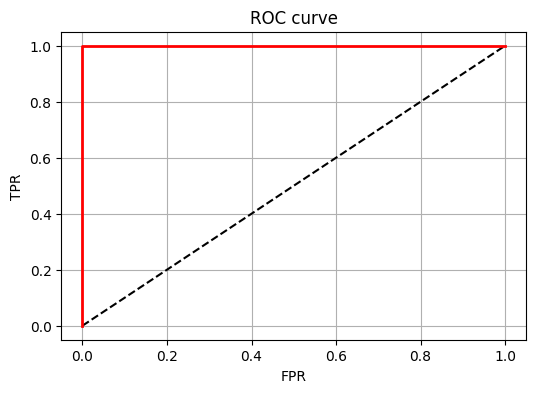

In [36]:
#ROC Curve
from sklearn.metrics import roc_curve
y_pred_prob=best_extra_trees.predict_proba(x_test)[:,1]
fpr,tpr,threshold=roc_curve(y_test,y_pred_prob)

plt.figure(figsize=(6,4))
plt.plot([0,1],[0,1], 'k--')
plt.plot(fpr,tpr,color='red',linewidth=2)
plt.grid()
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve')
plt.show()

In [37]:
results_df

,precision,recall
Naive bayes,0.986012,0.985644
KNN,1.000000,1.000000
Decision tree,1.000000,1.000000
Random forest,1.000000,1.000000
SVM,1.000000,1.000000
LR,1.000000,1.000000
ANN,0.998772,0.998769
Gradient Boosting,1.000000,1.000000
XGBoost,1.000000,1.000000
LightGBM,1.000000,1.000000
